In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf

In [52]:
# image1 = cv2.imread("faces/img01.jpg")
# cv2.imshow("FACE", image1)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [53]:
face_images = [] # 반리스트
face_images.clear()
for i in range(15):

    file = "./faces/img{0:02d}.jpg".format(i + 1)
    image = cv2.imread(file)
    image = cv2.resize(image, (64, 64)) # 64 X 64 RGB -> BGR
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR -> RGB
    face_images.append(image)

In [54]:
print(face_images[0])

[[[  7   8  10]
  [  5   7   6]
  [ 14  14  14]
  ...
  [212 231 235]
  [215 235 236]
  [214 234 233]]

 [[ 10  11  13]
  [  7   8   9]
  [ 12  12  12]
  ...
  [206 225 229]
  [202 222 223]
  [208 228 227]]

 [[ 12  13  15]
  [  9   9  11]
  [ 10  10  11]
  ...
  [206 225 227]
  [209 229 229]
  [212 232 230]]

 ...

 [[103  66  48]
  [110  73  55]
  [111  74  55]
  ...
  [215 231 231]
  [217 233 233]
  [217 232 235]]

 [[ 99  62  45]
  [110  74  56]
  [115  78  59]
  ...
  [216 232 232]
  [217 233 234]
  [217 232 235]]

 [[ 97  61  45]
  [105  70  51]
  [108  71  53]
  ...
  [217 233 233]
  [217 232 235]
  [216 231 234]]]


In [55]:
def show_image(row, col, images):
    (_, ax) = plt.subplots(row, col, figsize=(row,col))
    for i in range(row):
        for j in range(col):
            if row <= 1:
                axis = ax[j]
            else:
                axis = ax[i, j]
                axis.imshow(images[i * col + j])
                axis.axis("off")
    plt.show()

In [56]:
animal_images = [] # im
animal_images.clear()
for i in range(15):
    file = "./animals/img{0:02d}.jpg".format(i + 1)
    image = cv2.imread(file)
    image = cv2.resize(image, (64, 64)) # 64 X 64 RGB -> BGR
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR -> RGB
    animal_images.append(image)

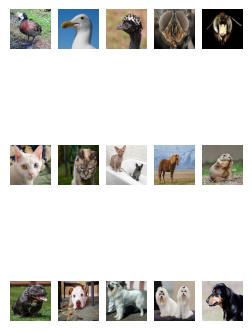

In [57]:
show_image(3, 5, animal_images)

In [58]:
# 레이블 만들기
y = [(1, 0 )] * len(face_images) + [(0, 1)] * len(animal_images)

In [59]:
print(y)

[(1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]


In [60]:
y = np.array(y)
print(y)

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]]


In [61]:
# Train Data
X = face_images + animal_images
print(X)
print(len(X))

[array([[[  7,   8,  10],
        [  5,   7,   6],
        [ 14,  14,  14],
        ...,
        [212, 231, 235],
        [215, 235, 236],
        [214, 234, 233]],

       [[ 10,  11,  13],
        [  7,   8,   9],
        [ 12,  12,  12],
        ...,
        [206, 225, 229],
        [202, 222, 223],
        [208, 228, 227]],

       [[ 12,  13,  15],
        [  9,   9,  11],
        [ 10,  10,  11],
        ...,
        [206, 225, 227],
        [209, 229, 229],
        [212, 232, 230]],

       ...,

       [[103,  66,  48],
        [110,  73,  55],
        [111,  74,  55],
        ...,
        [215, 231, 231],
        [217, 233, 233],
        [217, 232, 235]],

       [[ 99,  62,  45],
        [110,  74,  56],
        [115,  78,  59],
        ...,
        [216, 232, 232],
        [217, 233, 234],
        [217, 232, 235]],

       [[ 97,  61,  45],
        [105,  70,  51],
        [108,  71,  53],
        ...,
        [217, 233, 233],
        [217, 232, 235],
        [216, 231, 234]

In [62]:
X_train = np.array(X) #넘파이 배열
X_train = X_train / 255.0 #정규화

In [63]:
print(X_train.shape)

(30, 64, 64, 3)


In [64]:
# 학습할 모델 만들기
model = keras.Sequential(name="FACE_DETECTOR")
model.add(keras.layers.Input(shape=(64, 64, 3)))
# Convolution : Correlation
model.add(keras.layers.Conv2D(128, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(keras.layers.Conv2D(64, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(keras.layers.Conv2D(32, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2))
model.add(keras.layers.Conv2D(32, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2))
# DNN
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(64, activation="relu"))
model.add(keras.layers.Dense(64, activation="relu"))
model.add(keras.layers.Dense(32, activation="relu"))
model.add(keras.layers.Dense(2, activation="softmax"))

In [65]:
model.summary()

Model: "FACE_DETECTOR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,650 (467.38 KB)

 Trainable params: 119,650 (467.38 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["categorical_accuracy"])

In [67]:
history = model.fit(X_train, y, epochs=200)
model.save("FACE_DETECTOR.keras")

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step - categorical_accuracy: 0.6333 - loss: 0.6929
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - categorical_accuracy: 0.5333 - loss: 0.6902
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - categorical_accuracy: 0.5333 - loss: 0.6904
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - categorical_accuracy: 0.7333 - loss: 0.6799
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - categorical_accuracy: 0.5333 - loss: 0.6750
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - categorical_accuracy: 0.7333 - loss: 0.6636
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - categorical_accuracy: 0.7667 - loss: 0.6506
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - categorical_accuracy: 0.6667 - loss: 0.6337
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - categorical_accuracy: 0.8000 - loss: 0.6128
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - categorical_accuracy: 0.8000 - loss: 0.5839
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [68]:
print(f'모델정확도 : {model.evaluate(X_train, y)}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - categorical_accuracy: 1.0000 - loss: 5.9304e-05
모델정확도 : [5.9304416936356574e-05, 1.0]


In [78]:
test_images = []
test_images.clear()
for i in range(10):
    file = "./test_images/img{0:02d}.jpg".format(i + 1)
    image = cv2.imread(file)
    image = cv2.resize(image, (64, 64)) # 64 X 64 RGB -> BGR
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR -> RGB
    test_images.append(image)

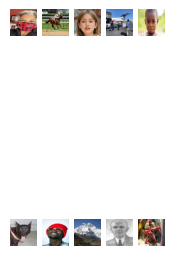

In [83]:
show_image(2, 5, test_images)
test_images = np.array(test_images) / 255.0
test_images = test_images.astype('float32')
#test_images = np.array(test_images)

In [80]:
cnn_model = keras.models.load_model("FACE_DETECTOR.keras")
cnn_model.predict(test_images)
#predict = model.predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([[9.9994493e-01, 5.5086595e-05],
       [8.3832953e-07, 9.9999917e-01],
       [9.9847406e-01, 1.5259412e-03],
       [3.0371220e-07, 9.9999964e-01],
       [1.0000000e+00, 1.4017795e-10],
       [9.9784553e-01, 2.1544273e-03],
       [1.0000000e+00, 3.5123936e-08],
       [1.1257778e-07, 9.9999988e-01],
       [9.9835265e-01, 1.6473752e-03],
       [6.2125843e-02, 9.3787414e-01]], dtype=float32)

In [81]:
print(cnn_model.predict(test_images))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[9.9994493e-01 5.5086595e-05]
 [8.3832953e-07 9.9999917e-01]
 [9.9847406e-01 1.5259412e-03]
 [3.0371220e-07 9.9999964e-01]
 [1.0000000e+00 1.4017795e-10]
 [9.9784553e-01 2.1544273e-03]
 [1.0000000e+00 3.5123936e-08]
 [1.1257778e-07 9.9999988e-01]
 [9.9835265e-01 1.6473752e-03]
 [6.2125843e-02 9.3787414e-01]]


In [82]:
print(cnn_model.predict(test_images).round(3)) #1.0 사람이다. 0.1 사람이 아니다

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[1.    0.   ]
 [0.    1.   ]
 [0.998 0.002]
 [0.    1.   ]
 [1.    0.   ]
 [0.998 0.002]
 [1.    0.   ]
 [0.    1.   ]
 [0.998 0.002]
 [0.062 0.938]]
